### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


### Cell 0 - Import ###

In [31]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
grades_df = pd.read_csv('grades_crpt.csv')

### Cell 1 - Explore Data set ###

In [33]:
import pandas as pd

df = pd.read_csv('grades_crpt.csv')

print(df.shape)
print(df.dtypes)
df.describe()



(86, 9)
A1            float64
A2            float64
A3            float64
A4            float64
A5            float64
A6            float64
A7            float64
Final_Exam    float64
user_id        object
dtype: object


,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


**Result**
- The dataset has 86 students and 9 columns (A1–A7, Final_Exam, user_id)
- A1 has the most missing data (29 missing or ~34%), Final_Exam has none
- Negative grades exist throughout the data with no pattern 
- Some grades exceed far 100+ beyond what grades/+bonus marks allow


### Cell 2 - Check the correlations ###

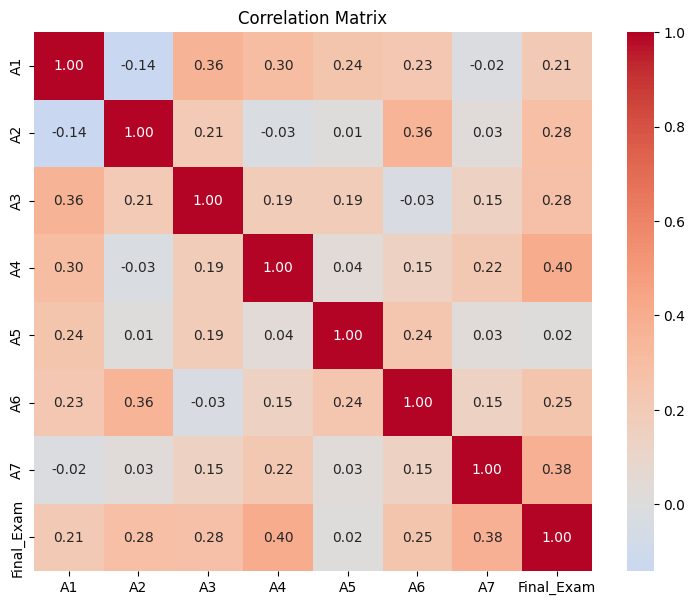

In [34]:
grade_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr = df[grade_cols].corr()


plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


I created a correlation matrix using the assignment columns

**Result**
- Weak Correlation              :   A5
- Moderate Correlation          :   A1, A2, A3, A6
- Moderate-Strong Correlation   :   A4, A7

*if you could only use two assignments to predict the final exam?*

A4 and A7 would be the best assignments to predict the final exam outcome

### Cell 3 - Removing Negative Values###

In [38]:
grade_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

neg_count = (df[grade_cols] < 0).sum()
print("Negative values removed per column:")
print(neg_count[neg_count > 0])

df[grade_cols] = df[grade_cols].where(df[grade_cols] >= 0)


Negative values removed per column:
A1    1
A2    1
A3    4
A4    1
A6    1
dtype: int64


Because the negative values looked fairly unreasonable, I have chosen to remove them and fill them back in during the next step.

### Cell 3 - Check for missing values ###

In [41]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})


,Missing Count,Missing %
A1,30,34.9
A2,26,30.2
A3,28,32.6
A4,10,11.6
A5,25,29.1
A6,20,23.3
A7,10,11.6
Final_Exam,0,0.0
user_id,0,0.0


**Result**
- Final_Exam and user_id have no missing values
- A1 has the most missing data: 29 out of 86 students (33.7%)
- A4 and A7 have the least: 9 (10.5%) and 10 (11.6%) respectively -> likely why the final exam correlation was moderately strong


### Cell 4 - Handle the missing values ###

In [49]:
features = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']

# Mean imputation
df_mean = df.copy()
df_mean[features] = df_mean[features].fillna(df_mean[features].mean())

# Median imputation
df_median = df.copy()
df_median[features] = df_median[features].fillna(df_median[features].median())

print("=== Missing values remaining ===")
print(f"Original:          {df[features].isnull().sum().sum()}")
print(f"Mean imputation:   {df_mean[features].isnull().sum().sum()}")
print(f"Median imputation: {df_median[features].isnull().sum().sum()}")

print("\n=== Std comparison (original vs imputed) ===")
comparison = pd.DataFrame({
    'Original':  df[features].std(),
    'Mean imp':  df_mean[features].std(),
    'Median imp': df_median[features].std(),
    'Drop (per col)': [df[col].dropna().std() for col in features]
}).round(2)
print(comparison)

print("\n=== Mean comparison ===")
means = pd.DataFrame({
    'Original':  df[features].mean(),
    'Mean imp':  df_mean[features].mean(),
    'Median imp': df_median[features].mean(),
    'Drop (per col)': [df[col].dropna().mean() for col in features]
}).round(2)
print(means)


=== Missing values remaining ===
Original:          149
Mean imputation:   0
Median imputation: 0

=== Std comparison (original vs imputed) ===
    Original  Mean imp  Median imp  Drop (per col)
A1     32.45     26.10       26.13           32.45
A2     24.79     20.65       21.07           24.79
A3     31.91     26.13       26.22           31.91
A4     37.46     35.19       35.21           37.46
A5     25.51     21.43       21.57           25.51
A6     29.26     25.59       25.65           29.26
A7     26.41     24.81       24.82           26.41

=== Mean comparison ===
    Original  Mean imp  Median imp  Drop (per col)
A1     85.25     85.25       86.03           85.25
A2     82.96     82.96       85.69           82.96
A3     75.40     75.40       76.90           75.40
A4     83.70     83.70       84.14           83.70
A5     89.65     89.65       91.20           89.65
A6     75.82     75.82       76.79           75.82
A7     78.13     78.13       78.35           78.13


For this step I used mean, median, and drop imputations to fill in each. Specifically for  the drop, I removed the rows that were missing per column.

**Results**
- Mean imputation keeps the means the same but reduces spread (std drops, e.g. A1: 32.45 → 26.10)
- Median imputation slightly raises the means and also reduces spread
- Drop preserves the original mean and std exactly, but with fewer data points

Overall, dropping produces the most honest answer. However if we need to fill in the actual grades then we should use mean to preserve the assignments average.

### Cell 5- Check for outliers ###

In [ ]:
def detect_outliers(df, column):
    mean = df[column].mean()
    std = df[column].std()
    lower_bound = mean - 2 * std
    upper_bound = mean + 2 * std
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

features = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

print("=== Outliers detected (mean +-2 std) ===")
for col in features:
    outliers = detect_outliers(df, col)
    if len(outliers) > 0:
        print(f"\n{col}: {len(outliers)} outliers")
        print(f"  Values: {sorted(outliers[col].dropna().values)}")


=== Outliers detected (mean ± 2 std) ===

A1: 5 outliers
  Values: [np.float64(0.0), np.float64(0.0), np.float64(168.1), np.float64(168.9), np.float64(174.6)]

A2: 4 outliers
  Values: [np.float64(0.0), np.float64(7.1), np.float64(32.1), np.float64(148.9)]

A3: 6 outliers
  Values: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(149.2), np.float64(150.8), np.float64(152.2)]

A4: 7 outliers
  Values: [np.float64(0.0), np.float64(0.0), np.float64(174.8), np.float64(175.8), np.float64(183.1), np.float64(187.1), np.float64(188.2)]

A5: 2 outliers
  Values: [np.float64(7.7), np.float64(173.9)]

A6: 3 outliers
  Values: [np.float64(0.0), np.float64(136.4), np.float64(183.6)]

A7: 8 outliers
  Values: [np.float64(0.0), np.float64(0.0), np.float64(12.2), np.float64(12.3), np.float64(136.9), np.float64(142.1), np.float64(146.4), np.float64(150.6)]

Final_Exam: 3 outliers
  Values: [np.float64(0.0), np.float64(0.0), np.float64(97.5)]


**Process**
- To detect the outliers I used the same method from the lab and checked for values with +-2 stds away. 

**Results**
- even with bonus points accounted for assignments 2,4, and 6 almost all upper outliers seemed unreasonable.
- Assignments that have not been submitted would result in a 0 so most lower outliers seem reasonable 


*How would I deal with outliers*

- remove all upper outliers as they seem overly inflated
- Keep the lower outliers as assignments might not have been submitted and/or the grade range is still within 0-100%
